In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from google.colab import files

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

import time
!pip install python-docx
from docx import Document
from docx.shared import Inches

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 3.3 MB/s eta 0:00:00


In [ ]:
#Reading df_basic
df_name = 'df_basic_1.3_no_NA' # resized (64,64), grey, masked, Nan deleted or replaced by mean

drive.mount('/content/drive')
df_basic = pd.read_pickle("/content/drive/My Drive/Team Project X-Rays/Dataframes/df_basic_1.3_no_NA.pkl")
# Setting the image name as Index and display the first 5 lines
df_basic = df_basic.set_index('Name')
df_basic.head()

Mounted at /content/drive


,Case,PX_407,PX_408,PX_409,PX_410,PX_411,PX_423,PX_424,PX_425,PX_426,...,PX_3257,PX_3274,PX_3275,PX_3316,PX_3317,PX_3318,PX_3319,PX_3320,PX_3382,PX_3383
Name,,,,,,,,,,,,,,,,,,,,,
COVID-1240,COVID,0.435316,0.430157,0.42887,0.431693,0.438176,0.422108,0.416397,0.412695,0.416362,...,0.463969,0.437964,0.592157,0.623529,0.639216,0.432121,0.439167,0.443240,0.434326,0.439705
COVID-1508,COVID,0.435316,0.430157,0.42887,0.431693,0.438176,0.422108,0.416397,0.412695,0.416362,...,0.463969,0.437964,0.438279,0.429313,0.430043,0.432121,0.439167,0.443240,0.434326,0.439705
COVID-1153,COVID,0.435316,0.430157,0.42887,0.431693,0.438176,0.422108,0.416397,0.412695,0.416362,...,0.364706,0.437964,0.438279,0.368627,0.349020,0.384314,0.356863,0.329412,0.349020,0.372549
COVID-1984,COVID,0.435316,0.430157,0.42887,0.431693,0.438176,0.422108,0.416397,0.412695,0.416362,...,0.463969,0.437964,0.438279,0.429313,0.430043,0.432121,0.439167,0.443240,0.434326,0.439705
COVID-3351,COVID,0.435316,0.430157,0.42887,0.431693,0.615686,0.422108,0.416397,0.412695,0.549020,...,0.298039,0.437964,0.438279,0.429313,0.430043,0.432121,0.439167,0.443240,0.434326,0.439705


In [ ]:
# Encode classes as numbers (LabelEncoder)
le = LabelEncoder()
df_basic['Case'] = le.fit_transform(df_basic['Case'])

# Splitting data into features (X) and target (y)
X = df_basic.drop('Case', axis=1)
y = df_basic['Case']

# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)


**PCA (Principal component analysis)**

In [ ]:
### --- PCA (Principal component analysis) --- ###

# Instantiating a PCA object (It shall generate as many components that are needed in order to explain 90 % of the datas variability)
pca = PCA(n_components = 0.9)

# Fit and transform the data
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


The number of components needed to explain 90 % of the datas variability are: 190
The first two components explain 44.999998807907104 % of the variability.


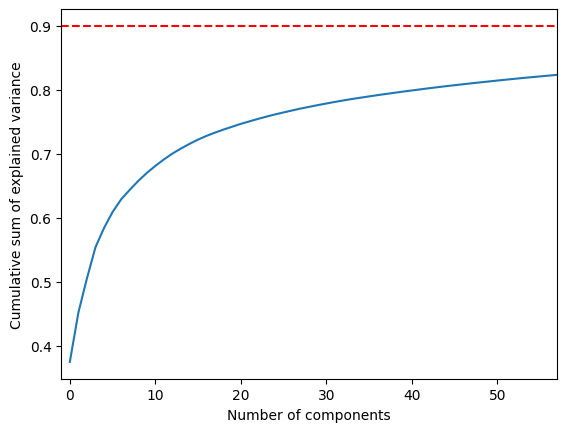

In [ ]:
# Report of how many dimensions are necessary to keep the majority of the informational content
print(f'The number of components needed to explain 90 % of the datas variability are: {pca.n_components_}')
print(f"The first two components explain {round(pca.explained_variance_ratio_[0:2].sum(),2)*100} % of the variability.")

# Plot the cumulative sum of the explained variance
plt.figure()
plt.xlim(-1, 57)
plt.xlabel('Number of components')
plt.ylabel('Cumulative sum of explained variance')
plt.axhline(y = 0.9, color = 'r', linestyle = '--')
plt.plot(pca.explained_variance_ratio_.cumsum());

# Save image as .png
plt.savefig(f'/content/PCA_Cumulative sum of explained variance_{df_name}.png', bbox_inches = 'tight')


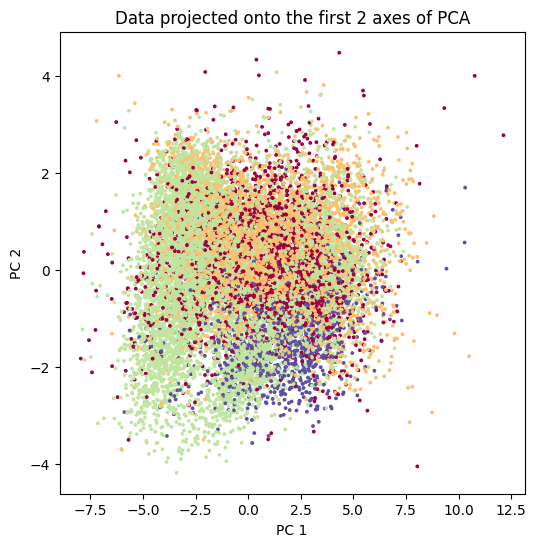

In [ ]:
# Plot the observations using the first two components of the PCA
plt.figure(figsize = (6,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c = y_train, s = 3, cmap=plt.cm.Spectral);
plt.xlabel('PC 1')
plt.ylabel('PC 2')

plt.title("Data projected onto the first 2 axes of PCA")

# Save image as .png
plt.savefig(f'/content/PCA_Data projected onto the first 2 axes of PCA_{df_name}.png', bbox_inches = 'tight')


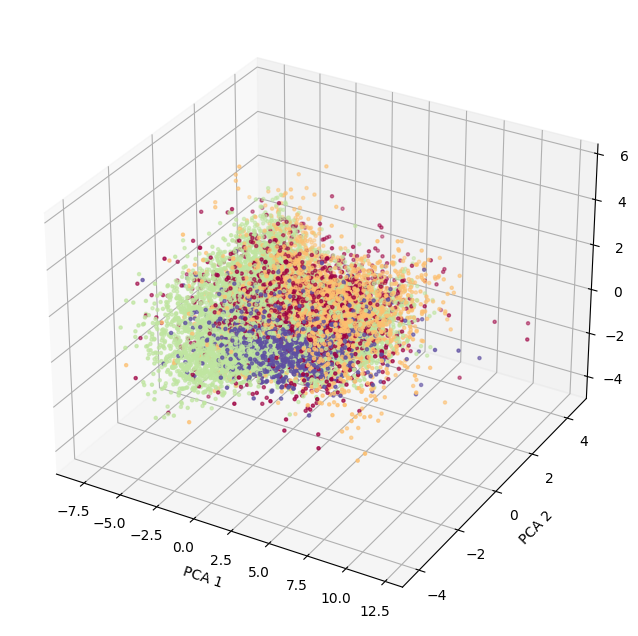

In [ ]:
# 3D plot of the first 3 principle components
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_train_pca[:,0], X_train_pca[:,1], X_train_pca[:,2], c = y_train, s = 5, cmap=plt.cm.Spectral)
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')

# Save image as .png
plt.savefig(f'/content/PCA_3D plot of the first 3 principle components_{df_name}.png', bbox_inches = 'tight')


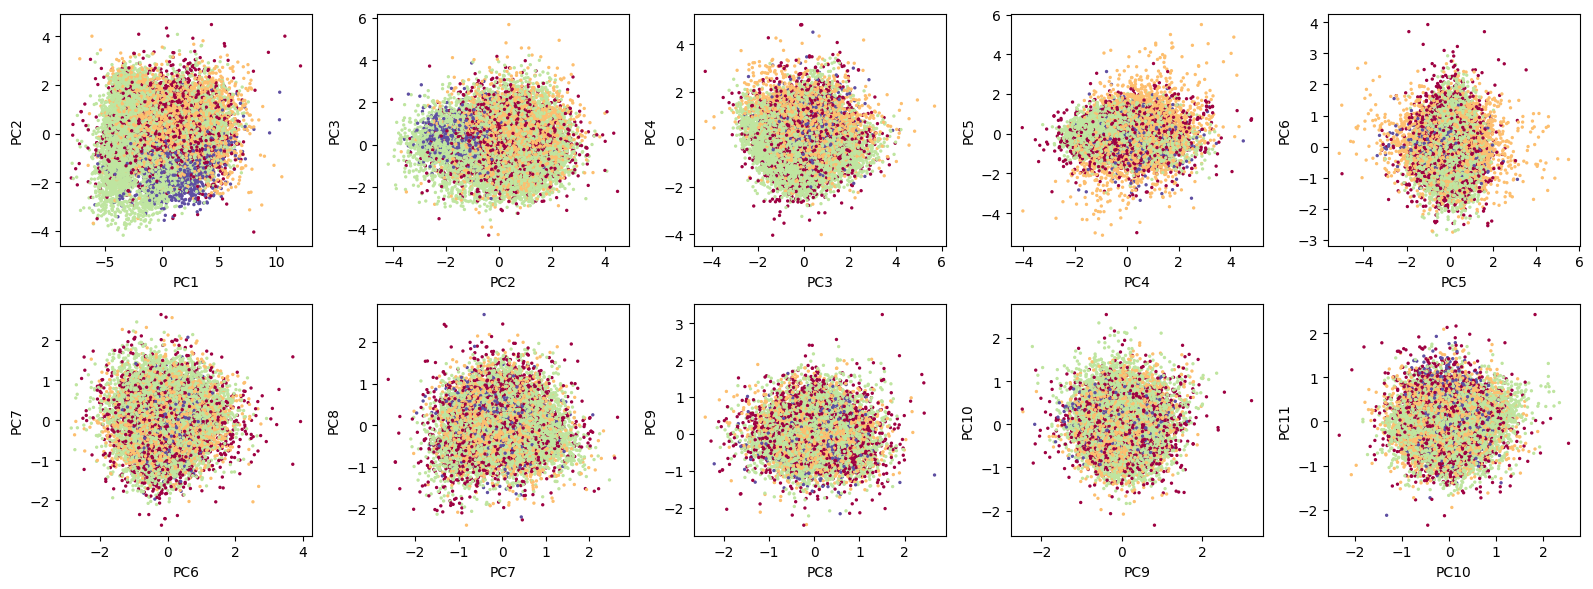

In [ ]:
# Plot the observations projected onto the different PC axes in decreasing order/importance
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for i in np.arange(0,10):
    ax = axes[i // 5, i % 5]
    ax.scatter(X_train_pca[:, i], X_train_pca[:, i+1], c=y_train, s=2, cmap=plt.cm.Spectral);
    ax.set_xlabel(f'PC{i+1}')
    ax.set_ylabel(f'PC{i+2}')

plt.tight_layout()

# Save image as .png
plt.savefig(f'/content/PCA_observations projected onto the different PC axes in decreasing importance_{df_name}.png', bbox_inches = 'tight')


**LDA (Linear discriminant analysis)**

In [ ]:
### --- LDA (Linear discriminant analysis) --- ###

lda = LDA()
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)


In [ ]:
# Print the shape
X_train_lda.shape


(16884, 3)

Train score: 0.6745439469320066
Test score: 0.5797204453920872


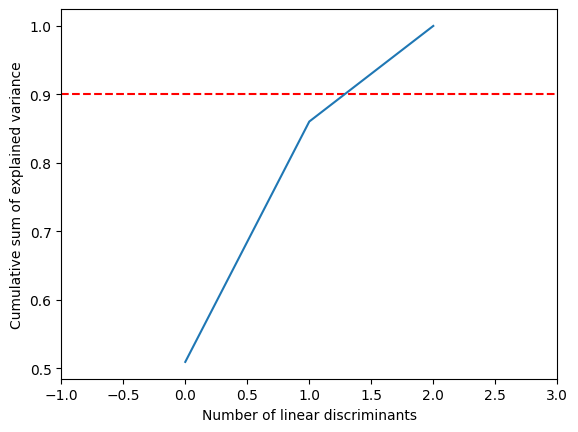

In [ ]:
# Plot the cumulative sum of the explained variance
plt.figure()
plt.xlim(-1, 3)
plt.xlabel('Number of linear discriminants')
plt.ylabel('Cumulative sum of explained variance')
plt.axhline(y = 0.9, color = 'r', linestyle = '--')
plt.plot(lda.explained_variance_ratio_.cumsum())

# Save image as .png
plt.savefig(f'/content/LDA_Cumulative sum of the explained variance_{df_name}.png', bbox_inches = 'tight')

# Assess the score of 'LDA classification'
print(f'Train score: {lda.score(X_train, y_train)}')
print(f'Test score: {lda.score(X_test, y_test)}')

The first two components explain 86.00000143051147 % of the variability.


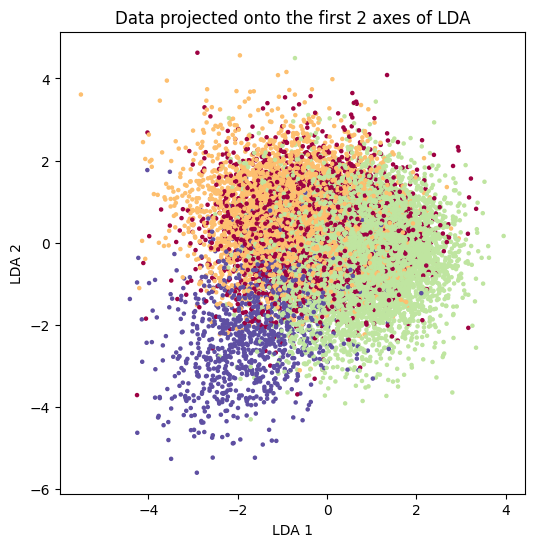

In [ ]:
# Report the explained variance for the first two components
print(f"The first two components explain {round(lda.explained_variance_ratio_[0:2].sum(),3)*100} % of the variability.")

# Plot the observations using the first two components of the LDA
plt.figure(figsize = (6,6))
plt.scatter(X_train_lda[:,0], X_train_lda [:,1], c = y_train, s = 5, cmap=plt.cm.Spectral);
plt.xlabel('LDA 1')
plt.ylabel('LDA 2')

plt.title("Data projected onto the first 2 axes of LDA")

# Save image as .png
plt.savefig(f'/content/LDA_Data projected onto the first 2 axes of LDA_{df_name}.png', bbox_inches = 'tight')

# THOUGHTS:
# The 4 classes can be separate partially. The green and the purple class are separated quite well. Red and orange not so much.
# Much better result then for the PCA method

# ACTIONS:
# Try 3D plot of the first 3 components
# look at the correlation of pixels and PCs in order to interpret which areas are important


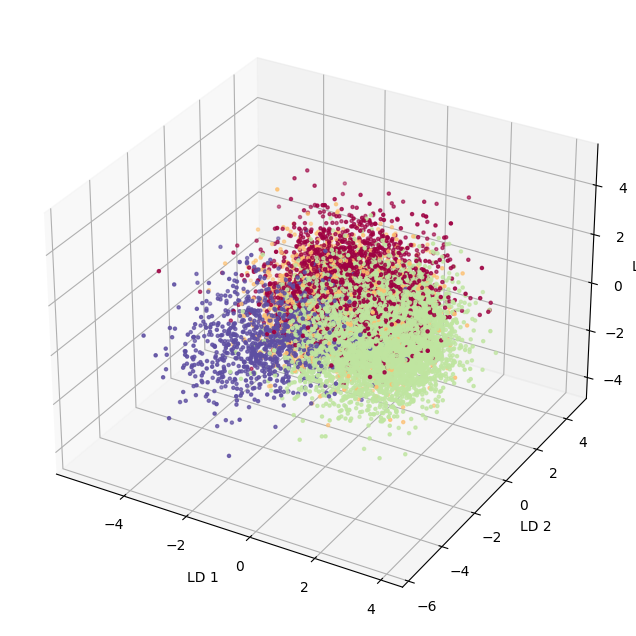

In [ ]:
# 3D plot of all 3 linear discriminants
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(projection='3d')
ax.scatter(X_train_lda[:,0], X_train_lda[:,1], X_train_lda[:,2], c = y_train, s = 5, cmap=plt.cm.Spectral)
ax.set_xlabel('LD 1')
ax.set_ylabel('LD 2')
ax.set_zlabel('LD 3')

# Save image as .png
plt.savefig(f'/content/LDA_3D plot of all 3 linear discriminants_{df_name}.png', bbox_inches = 'tight')

# With the third dimension the separation of classes gets even clearer


In [ ]:
# Generate random data for test purposes
np.random.seed(0)  # For reproducibility
data = np.random.randn(100, 9)  # 9 feature columns

# Create target column with integers 1-4
target = np.random.randint(1, 5, size=(100, 1))

# Concatenate target and feature columns
data = np.hstack((target, data))

# Create a DataFrame
df = pd.DataFrame(data, columns=['target'] + [f'feature_{i}' for i in range(9)])
display(df.head())

# Encode classes as numbers (LabelEncoder)
lenc = LabelEncoder()
df['target'] = lenc.fit_transform(df['target'])

data = df.drop('target', axis=1)
target = df['target']

# Splitting data into training and testing sets
X_train__check, X_test__check, y_train_check, y_test_check = train_test_split(data, target, test_size=0.2)


,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8
0,3.0,1.764052,0.400157,0.978738,2.240893,1.867558,-0.977278,0.950088,-0.151357,-0.103219
1,4.0,0.410599,0.144044,1.454274,0.761038,0.121675,0.443863,0.333674,1.494079,-0.205158
2,2.0,0.313068,-0.854096,-2.552990,0.653619,0.864436,-0.742165,2.269755,-1.454366,0.045759
3,2.0,-0.187184,1.532779,1.469359,0.154947,0.378163,-0.887786,-1.980796,-0.347912,0.156349
4,3.0,1.230291,1.202380,-0.387327,-0.302303,-1.048553,-1.420018,-1.706270,1.950775,-0.509652


In [ ]:
### --- Test predictive performance with different techniques of dimension reduction applied to the data set --- ###

# Setting up four different models
lr = LogisticRegression(solver='lbfgs', C = 1.0, max_iter=10000)
knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski')
svc = SVC(gamma = 0.01, kernel = "poly")
dt = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=123)

# Define function to test model performance
def test_performance(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    cl_report = classification_report(y_te, model.predict(X_te), output_dict=True)
    cl_report_df = pd.DataFrame(cl_report).transpose()
    f1_scores_covid = cl_report_df.iloc[le.transform(['COVID'])[0]]['f1-score']
    f1_score_opacity = cl_report_df.iloc[le.transform(['Lung_Opacity'])[0]]['f1-score']
    f1_score_normal = cl_report_df.iloc[le.transform(['Normal'])[0]]['f1-score']
    f1_score_pneumonia = cl_report_df.iloc[le.transform(['Viral Pneumonia'])[0]]['f1-score']
    return model.score(X_train, y_train), model.score(X_test, y_test), f1_scores_covid, f1_score_opacity, f1_score_normal, f1_score_pneumonia


# Create list of data sets to be analysed
datasets = [
    (X_train, X_test, y_train, y_test, 'No dimension reduction'),
    (X_train_pca, X_test_pca, y_train, y_test, 'PCA'),
    (X_train_lda, X_test_lda, y_train, y_test, 'LDA'),
    #(X_train__check, X_test__check, y_train_check, y_test_check, 'check')
    ]

# Create list of models to be tested
models = [
    (lr, 'LogisticRegression'),
     (knn, 'KNeighbors'),
      (svc, 'SVC'),
       (dt, 'DecisionTree')
       ]

# Create empty lists to store results
model_names =[]
dataset_names = []
model_scores = []
execution_times = []

# Loop through the different models and data sets to determine the
# performance of each model on each test set
for model, model_name in models:
  for X_tr, X_te, y_tr, y_te, dataset_name in datasets:
    # Add model name to list
    model_names.append(model_name)
    # Add dataset name to the list
    dataset_names.append(dataset_name)
    # Record the start time
    start_time = time.time()
    # Fit model and calculate train and test score
    model_scores.append(test_performance(X_tr, X_te, y_tr, y_te,model))
    # Record the end time
    end_time = time.time()
    # Calculate the execution time
    execution_time = (end_time - start_time)/60
    # Add execution time to the list
    execution_times.append(execution_time)

# Create a DataFrame with the results and display it
results = pd.DataFrame({'Model': model_names, 'Dataset': dataset_names, 'Train_accuracy': np.array(model_scores)[:,0], 'Test_accuracy': np.array(model_scores)[:,1], 'f1_covid' : np.array(model_scores)[:,2],
                        'f1_lung_opacity' : np.array(model_scores)[:,3], 'f1_normal' : np.array(model_scores)[:,4], 'f1_pneumonia' : np.array(model_scores)[:,5], 'f1_mean' : np.array(model_scores)[:,2:6].mean(axis=1), 'Execution time [min]': execution_times})
display(results)


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif

,Model,Dataset,Train_accuracy,Test_accuracy,f1_covid,f1_lung_opacity,f1_normal,f1_pneumonia,f1_mean,Execution time [min]
0,LogisticRegression,No dimension reduction,0.679401,0.589434,0.195169,0.549335,0.716626,0.462527,0.480914,5.160774
1,LogisticRegression,PCA,0.630360,0.621417,0.140553,0.588143,0.741210,0.517857,0.496941,0.055477
2,LogisticRegression,LDA,0.676795,0.581616,0.199078,0.544207,0.711918,0.442105,0.474327,0.001630
3,KNeighbors,No dimension reduction,0.732824,0.669747,0.343643,0.662420,0.782099,0.434018,0.555545,1.065661
4,KNeighbors,PCA,0.769486,0.712390,0.420495,0.693101,0.810615,0.569921,0.623533,0.173116
5,KNeighbors,LDA,0.716951,0.556029,0.219797,0.517893,0.694972,0.425439,0.464525,0.024131
6,SVC,No dimension reduction,0.783108,0.677565,0.272545,0.664274,0.785778,0.564220,0.571704,11.856202
7,SVC,PCA,0.510483,0.506752,0.000000,0.169562,0.665786,0.000000,0.208837,2.335727
8,SVC,LDA,0.497986,0.491116,0.002899,0.026688,0.654169,0.213793,0.224387,0.351007
9,DecisionTree,No dimension reduction,0.572909,0.565980,0.008403,0.565342,0.691934,0.000000,0.316420,0.081398


In [ ]:
# Save the DataFrame as a CSV file
results.to_excel(f'/content/Model performance before and after dimension reduction_{df_name}.xlsx', index=False)

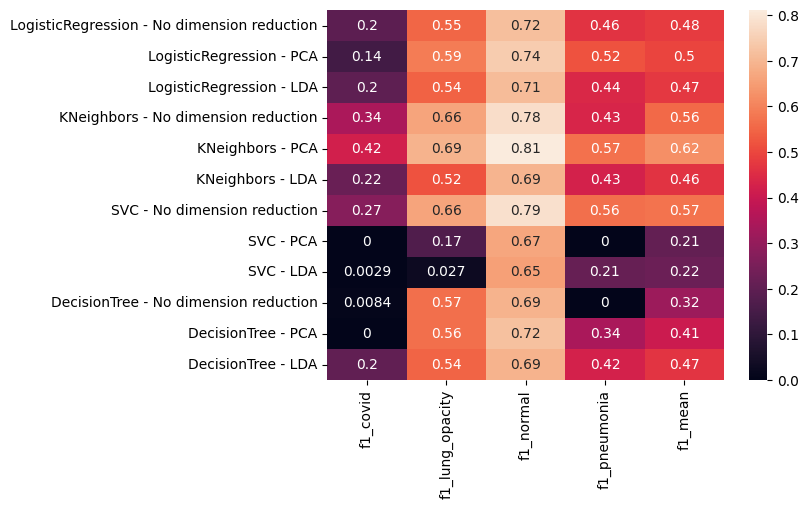

In [ ]:
# Create a heatmap for visual interpretation
orange_pallet = sns.color_palette("YlOrBr", as_cmap=True)
sns.heatmap(results[['f1_covid', 'f1_lung_opacity', 'f1_normal', 'f1_pneumonia', 'f1_mean']], yticklabels= results['Model']+' - '+results['Dataset'], annot = True)#, cmap = 'dark:salmon_r')

# Save image as .png
plt.savefig(f'/content/Heatmap_model_performance_{df_name}.png', bbox_inches = 'tight')


In [ ]:
# Insert grafics in word-docx
# Create a word document
doc = Document()

# Create a heading
doc.add_heading(f'The impact of dimension reduction - Images for the analysis of {df_name}', 0)

# Add graphs to the document
doc.add_picture(f'/content/PCA_Cumulative sum of explained variance_{df_name}.png')
doc.add_picture(f'/content/PCA_Data projected onto the first 2 axes of PCA_{df_name}.png')
doc.add_picture(f'/content/PCA_3D plot of the first 3 principle components_{df_name}.png')
# doc.add_picture(f'/content/PCA_Interpretation of PCA (which parts of the images are important)_{df_name}.png')
doc.add_picture(f'/content/PCA_observations projected onto the different PC axes in decreasing importance_{df_name}.png')
doc.add_picture(f'/content/LDA_Cumulative sum of the explained variance_{df_name}.png')
doc.add_picture(f'/content/LDA_Data projected onto the first 2 axes of LDA_{df_name}.png')
doc.add_picture(f'/content/LDA_3D plot of all 3 linear discriminants_{df_name}.png')
# doc.add_picture(f'/content/LDA_Interpretation of LDA (which parts of the images are important)_{df_name}.png')
# doc.add_picture(f'/content/Average image of each class_{df_name}.png')
doc.add_picture(f'/content/Heatmap_model_performance_{df_name}.png')

# Save word document
doc.save(f'The impact of dimension reduction - Images for the analysis of {df_name}.docx')



In [ ]:
# Downloads
files.download(f'/content/PCA_Cumulative sum of explained variance_{df_name}.png')
files.download(f'/content/PCA_Data projected onto the first 2 axes of PCA_{df_name}.png')
files.download(f'/content/PCA_3D plot of the first 3 principle components_{df_name}.png')
# files.download(f'/content/PCA_Interpretation of PCA (which parts of the images are important)_{df_name}.png')
files.download(f'/content/PCA_observations projected onto the different PC axes in decreasing importance_{df_name}.png')
files.download(f'/content/LDA_Cumulative sum of the explained variance_{df_name}.png')
files.download(f'/content/LDA_Data projected onto the first 2 axes of LDA_{df_name}.png')
files.download(f'/content/LDA_3D plot of all 3 linear discriminants_{df_name}.png')
# files.download(f'/content/LDA_Interpretation of LDA (which parts of the images are important)_{df_name}.png')
# files.download(f'/content/Average image of each class_{df_name}.png')
files.download(f'/content/Model performance before and after dimension reduction_{df_name}.xlsx')
files.download(f'/content/Heatmap_model_performance_{df_name}.png')
files.download(f'The impact of dimension reduction - Images for the analysis of {df_name}.docx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>